In [37]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.transforms.functional import normalize
import torchshow as ts
from torchvision.utils import draw_segmentation_masks

In [38]:
im_path = "/data/datasets/nii/MSD/Task08_HepaticVessel/imagesTr/hepaticvessel_384.nii.gz"
gt_path = "/data/datasets/nii/MSD/Task08_HepaticVessel/labelsTr/hepaticvessel_384.nii.gz"
im = nib.load(im_path).get_fdata()
gt = nib.load(gt_path).get_fdata()

In [39]:
im.shape, gt.shape

((512, 512, 158), (512, 512, 158))

In [40]:
scale = 255
im = torch.Tensor(im)
im = (im - im.min()) / (im.max() - im.min()) * scale
im = im.permute(2,0,1).unsqueeze(1).repeat(1,3,1,1)

gt = torch.Tensor(gt)
cats = gt.unique()[1:].unsqueeze(-1).unsqueeze(-1)
gt = gt.permute(2,0,1).unsqueeze(1).repeat(1,len(cats),1,1)
gt = (gt == cats)

In [41]:
gt.unique()

tensor([False,  True])

In [42]:
im.min(), im.max()

(tensor(0.), tensor(255.))

In [52]:
gt.sum(axis=(2, 3)).argwhere()

tensor([[ 53,   0],
        [ 54,   0],
        [ 55,   0],
        [ 56,   0],
        [ 57,   0],
        [ 58,   0],
        [ 59,   0],
        [ 60,   0],
        [ 61,   0],
        [ 62,   0],
        [ 63,   0],
        [ 64,   0],
        [ 65,   0],
        [ 66,   0],
        [ 67,   0],
        [ 68,   0],
        [ 69,   0],
        [ 70,   0],
        [ 70,   1],
        [ 71,   0],
        [ 71,   1],
        [ 72,   0],
        [ 72,   1],
        [ 73,   0],
        [ 73,   1],
        [ 74,   0],
        [ 74,   1],
        [ 75,   0],
        [ 75,   1],
        [ 76,   0],
        [ 76,   1],
        [ 77,   0],
        [ 77,   1],
        [ 78,   0],
        [ 78,   1],
        [ 79,   0],
        [ 80,   0],
        [ 81,   0],
        [ 82,   0],
        [ 83,   0],
        [ 84,   0],
        [ 85,   0],
        [ 86,   0],
        [ 87,   0],
        [ 88,   0],
        [ 89,   0],
        [ 90,   0],
        [ 91,   0],
        [ 92,   0],
        [ 93,   0],


In [44]:
im.shape, gt.shape

(torch.Size([158, 3, 512, 512]), torch.Size([158, 2, 512, 512]))

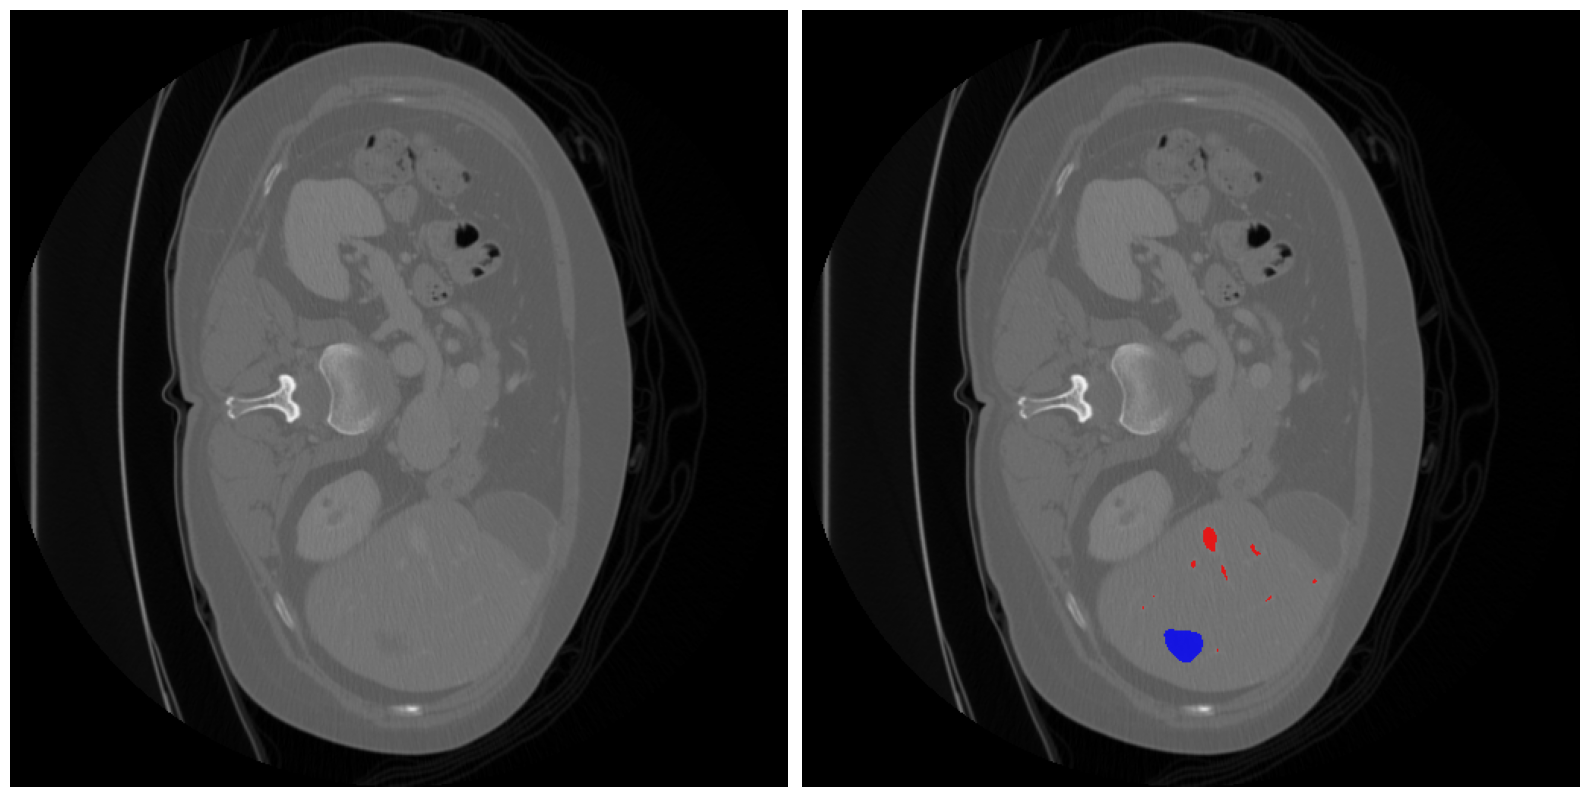

In [74]:
slice_idx = 72
draw_im, draw_gt = im[slice_idx].to(torch.uint8), gt[slice_idx].bool()
overlayed_image = draw_segmentation_masks(draw_im, draw_gt, alpha=0.8, colors=["red", "blue"])
ts.show([draw_im, overlayed_image], figsize=(16,16))